# Agentic ML classification — end-to-end pipeline

This notebook walks through the full pipeline cell by cell, using the
same functions the CLI scripts (`scripts/run_orchestrator.py` etc.)
call — nothing here is reimplemented, it's the same
`agentic_ml.steps.*` / `agentic_ml.harness.*` code, just run one phase
at a time so you can see the intermediate output.

Pipeline: **intake** (optional — infers the target column from a
natural-language goal or the schema alone) → **feature engineering**
(proposes columns to drop + stateless derived features from a vetted
catalog — safe to apply before the split even exists) → **profiler**
(deterministic facts + LLM narrative on the augmented columns; its
`recommended_split_strategy` drives the split) → **split + leakage
checks** → **modeling agent** (tries a few candidate template+config
proposals, each independently gated by two deterministic leakage
checks) → **verification agent** (a second-opinion audit that reviews
gate-passing candidates best-first and can only flag/reject — never
approve one that failed a gate — falling back to the next-best
candidate on a rejection) → **one locked test-set evaluation** →
**narrated summary**.

Requires a working `.env` (copy from `.env.example`) with `RIT_API_KEY`
/ `RIT_BASE_URL` set, or `MODEL_GATEWAY_BASE_URL` if using the gateway.
The API key is loaded but never printed anywhere in this notebook.

Every agent call also writes a full transcript (system prompt, tool
calls with real arguments, tool results, final response — not just
metadata) to `runs/<run_id>/transcripts/`, so you can open any of them
after the fact and read exactly what that agent saw and said. §12
shows an example.

## 0. Setup — locate the repo, load `.env`, import everything

In [19]:
import json
import os
import sys
from pathlib import Path

import pandas as pd
from IPython.display import display, Markdown


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "src" / "agentic_ml").exists():
            return candidate
    raise RuntimeError("Could not locate repo root (expected to find src/agentic_ml/ above cwd)")


REPO_ROOT = find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT / "src"))
os.chdir(REPO_ROOT)  # so relative paths (datasets/raw/..., runs/, artifacts/...) match the CLI scripts
print(f"Repo root: {REPO_ROOT}")

Repo root: /home/ubuntupc/Documents/Github/agentic-ai-project/agentic-ml-classification


In [20]:
def load_env_file(path: Path) -> None:
    if not path.exists():
        print(f"No .env file found at {path} — assuming environment variables are already set.")
        return
    for line in path.read_text().splitlines():
        line = line.strip()
        if not line or line.startswith("#") or "=" not in line:
            continue
        key, _, val = line.partition("=")
        os.environ.setdefault(key.strip(), val.strip().strip('"').strip("'"))


load_env_file(REPO_ROOT / ".env")
assert os.environ.get("RIT_API_KEY") or os.environ.get("MODEL_GATEWAY_BASE_URL"), (
    "No RIT_API_KEY or MODEL_GATEWAY_BASE_URL found. Copy .env.example to .env and fill in "
    "RIT_API_KEY / RIT_BASE_URL (or the gateway vars) before running this notebook."
)
print("Environment loaded (secrets not printed).")

Environment loaded (secrets not printed).


In [21]:
from sklearn.base import clone
from sklearn.metrics import auc, confusion_matrix, ConfusionMatrixDisplay, roc_curve
import matplotlib.pyplot as plt

from agentic_ml.cli_common import make_run_dir, make_tracer, make_transcript_writer, resolve_model_endpoint
from agentic_ml.harness.dataset import DatasetSpec, LoadedDataset, load_dataset, read_dataframe
from agentic_ml.harness.leaderboard import append_leaderboard_entry
from agentic_ml.harness.leakage import run_all_split_leakage_checks
from agentic_ml.harness.metrics import compute_metrics
from agentic_ml.harness.splits import make_split, resolve_split_columns
from agentic_ml.harness.verification import build_review_bundle
from agentic_ml.model_client import ModelClient
from agentic_ml.steps.feature_engineering_step import run_feature_engineering_step
from agentic_ml.steps.intake_step import run_intake_step
from agentic_ml.steps.modeling_step import run_modeling_step
from agentic_ml.steps.profiler_step import run_profiler_step
from agentic_ml.steps.verification_step import run_verification_step
from agentic_ml.templates.registry import get_template

print("Imports OK.")

Imports OK.


## 1. Configuration

Edit this cell for your dataset, then run everything below it in order.

- Leave `target_column` as `None` to let the **intake agent** infer it
  from `goal` (or from the schema alone if `goal` is also empty) — the
  "just a dataset" case.
- Set `target_column` explicitly to skip intake entirely.

In [22]:
TITANIC = False
CONFIG = {
    "data_path": "datasets/raw/train.csv" if TITANIC else "datasets/raw/iris.csv",
    "goal": "predict whether a passenger survived the Titanic disaster" if TITANIC else "predict the species of an iris flower",
    "target_column": None,        # e.g. "Survived" to skip intake
    "group_column": None,
    "time_column": None,
    "id_columns": None,           # comma-separated string, or None to let intake decide
    "strategy": None,             # None = use the profiler's recommendation
    "seed": 42,
    "metrics": ["roc_auc", "pr_auc", "f1", "accuracy"],
    "max_candidates": 2,
    "skip_feature_engineering": False,
    "model": None,                # None = RIT_DEFAULT_MODEL env var
    "verification_model": None,   # None = a reasoning-oriented default, distinct from "model"
    "use_gateway": False,
    "run_id": None,               # None = auto-generate
}
CONFIG

{'data_path': 'datasets/raw/iris.csv',
 'goal': 'predict the species of an iris flower',
 'target_column': None,
 'group_column': None,
 'time_column': None,
 'id_columns': None,
 'strategy': None,
 'seed': 42,
 'metrics': ['roc_auc', 'pr_auc', 'f1', 'accuracy'],
 'max_candidates': 2,
 'skip_feature_engineering': False,
 'model': None,
 'verification_model': None,
 'use_gateway': False,
 'run_id': None}

## 2. Model client + run directory

In [23]:
base_url, api_key, default_model = resolve_model_endpoint(
    CONFIG["use_gateway"], CONFIG["model"], "qwen3-coder:30b", "rit-qwen3-coder-30b",
)
client = ModelClient(base_url=base_url, api_key=api_key, default_model=default_model)

run_id, run_dir = make_run_dir(CONFIG["run_id"])
trace = make_tracer(run_dir / "trace.jsonl")
write_transcript = make_transcript_writer(run_dir)

print(f"run_id: {run_id}")
print(f"run_dir: {run_dir}")
print(f"model: {default_model}")

run_id: run_975e8055
run_dir: runs/run_975e8055
model: qwen3-coder:30b


## 3. Intake — figure out the dataset spec

Skipped if `CONFIG["target_column"]` is set. Otherwise the intake agent
sees only pre-target column facts (`get_raw_schema` — no target-dependent
stats exist yet) plus the natural-language `goal`, and proposes a
target/id/group/time column split. Its proposal is re-validated against
those same facts before anything downstream runs.

In [24]:
if CONFIG["target_column"] is None:
    raw_df = read_dataframe(CONFIG["data_path"])
    intake_result = run_intake_step(
        raw_df, CONFIG["goal"] or "", client, model=default_model,
        trace_fn=lambda r: trace(**r),
    )

    display(pd.DataFrame(intake_result.raw_schema["columns"]))
    print("IntakeAgent proposal:")
    print(json.dumps(intake_result.dataset_spec_proposal, indent=2))
    print(f"Transcript: {write_transcript('intake', intake_result.messages)}")

    assert intake_result.ok, f"Intake proposal failed validation: {intake_result.validation_errors}"

    proposal = intake_result.dataset_spec_proposal
    target_column = proposal["target_column"]
    group_column = CONFIG["group_column"] or proposal.get("group_column")
    time_column = CONFIG["time_column"] or proposal.get("time_column")
    id_columns = proposal.get("id_columns") or []
else:
    target_column = CONFIG["target_column"]
    group_column = CONFIG["group_column"]
    time_column = CONFIG["time_column"]
    id_columns = [c.strip() for c in (CONFIG["id_columns"] or "").split(",") if c.strip()]

print(f"\ntarget_column={target_column!r}  group_column={group_column!r}  "
      f"time_column={time_column!r}  id_columns={id_columns}")

,name,dtype,missing_frac,n_unique,unique_frac,sample_values,name_suggests_id,name_suggests_group,looks_like_datetime
0,Id,int64,0.0,150,1.0000,"[1, 2, 3]",True,False,False
1,SepalLengthCm,float64,0.0,35,0.2333,"[5.1, 4.9, 4.7]",False,False,False
2,SepalWidthCm,float64,0.0,23,0.1533,"[3.5, 3.0, 3.2]",False,False,False
3,PetalLengthCm,float64,0.0,43,0.2867,"[1.4, 1.4, 1.3]",False,False,False
4,PetalWidthCm,float64,0.0,22,0.1467,"[0.2, 0.2, 0.2]",False,False,False
5,Species,object,0.0,3,0.0200,"[Iris-setosa, Iris-setosa, Iris-setosa]",False,False,False


IntakeAgent proposal:
{
  "target_column": "Species",
  "task": "multiclass_classification",
  "id_columns": [
    "Id"
  ],
  "group_column": null,
  "time_column": null,
  "positive_label": null,
  "reasoning": "The Species column is the target because it represents the iris flower species, which is the outcome we want to predict. The Id column is excluded as it's a unique identifier that would not be predictive. The other columns (SepalLengthCm, SepalWidthCm, PetalLengthCm, PetalWidthCm) are features used for prediction. There are 3 unique values in Species, which fits the multiclass classification requirement."
}
Transcript: runs/run_975e8055/transcripts/intake_01.json

target_column='Species'  group_column=None  time_column=None  id_columns=['Id']


## 4. Load the dataset

In [25]:
raw_spec = DatasetSpec(
    path=CONFIG["data_path"], target_column=target_column,
    group_column=group_column, time_column=time_column, id_columns=id_columns,
)
raw_loaded = load_dataset(raw_spec)
display(raw_loaded.df.head())
print(f"{len(raw_loaded.df)} rows, {len(raw_loaded.df.columns)} columns, "
      f"data_hash={raw_loaded.data_hash[:16]}...")

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


150 rows, 6 columns, data_hash=0c4e0a81de3e7b35...


## 5. Feature Engineering agent

Proposes columns to drop and new derived columns from a vetted,
deterministic operation catalog (`harness/feature_engineering.py`) —
every op is stateless and row-wise, which is what makes it safe to
apply before the split even exists. It does NOT decide imputation
values or scaling — those stay inside the modeling templates,
unchanged. Skipped if `CONFIG["skip_feature_engineering"]` is set.

In [26]:
if CONFIG["skip_feature_engineering"]:
    print("Skipping FeatureEngineeringAgent.")
    final_id_columns = id_columns
    engineered_df = raw_loaded.df
else:
    fe_result = run_feature_engineering_step(
        raw_loaded.df, target_column, client,
        group_column=group_column, time_column=time_column,
        model=default_model, trace_fn=lambda r: trace(**r),
    )
    fe_transcript_path = write_transcript("feature_engineering", fe_result.messages)
    print(f"Transcript: {fe_transcript_path}")

    assert fe_result.ok, f"FeatureEngineeringAgent proposal failed validation: {fe_result.errors}"

    print(f"drop_columns: {fe_result.drop_columns}")
    print(f"new_columns: {fe_result.new_columns}")
    print(f"explanation: {fe_result.explanation}")

    final_id_columns = sorted(set(id_columns) | set(fe_result.drop_columns))
    engineered_df = fe_result.df

spec = DatasetSpec(
    path=CONFIG["data_path"], target_column=target_column,
    group_column=group_column, time_column=time_column, id_columns=final_id_columns,
)
# data_hash still traces back to the original raw file — the applied_ops
# above are what make the augmented columns reproducible from that data.
loaded = LoadedDataset(df=engineered_df, spec=spec, data_hash=raw_loaded.data_hash)
if len(loaded.df.columns) != len(raw_loaded.df.columns):
    display(loaded.df.head())
    print(f"Columns after feature engineering: {len(loaded.df.columns)} (was {len(raw_loaded.df.columns)})")

Transcript: runs/run_975e8055/transcripts/feature_engineering_01.json
drop_columns: ['Id']
new_columns: ['PetalLengthCm_over_PetalWidthCm', 'SepalLengthCm_times_SepalWidthCm', 'PetalLengthCm_times_PetalWidthCm']
explanation: The 'Id' column is dropped because it is flagged as a likely identifier column with 100% unique values, making it unsuitable for modeling. Three derived features are proposed: a ratio of PetalLengthCm to PetalWidthCm, and two interaction terms between Sepal and Petal dimensions. These combinations are expected to capture meaningful relationships between the features that may improve model performance.


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species,PetalLengthCm_over_PetalWidthCm,SepalLengthCm_times_SepalWidthCm,PetalLengthCm_times_PetalWidthCm
0,1,5.1,3.5,1.4,0.2,Iris-setosa,7.0,17.85,0.28
1,2,4.9,3.0,1.4,0.2,Iris-setosa,7.0,14.70,0.28
2,3,4.7,3.2,1.3,0.2,Iris-setosa,6.5,15.04,0.26
3,4,4.6,3.1,1.5,0.2,Iris-setosa,7.5,14.26,0.30
4,5,5.0,3.6,1.4,0.2,Iris-setosa,7.0,18.00,0.28


Columns after feature engineering: 9 (was 6)


## 6. Profiler agent

Deterministic code computes every fact (`harness/profiler.py`) over the
(possibly augmented) columns; the LLM only narrates and recommends —
it cannot change `recommended_split_strategy` or the leakage risk
flags.

In [27]:
profiler_result = run_profiler_step(
    loaded.df, target_column, client, model=default_model,
    trace_fn=lambda r: trace(**r),
)
assert profiler_result.ok, "ProfilerAgent never called get_dataset_profile."
profiler_transcript_path = write_transcript("profiler", profiler_result.messages)

dr = profiler_result.deterministic_report
display(pd.DataFrame(dr["columns"]))
print(f"recommended_split_strategy: {dr['recommended_split_strategy']}")
print(f"is_imbalanced: {dr['is_imbalanced']}  (ratio={dr['class_imbalance_ratio']})")
print(f"leakage_risk_flags: {dr['leakage_risk_flags']}")

display(Markdown(f"**Profiler narrative:**\n\n{profiler_result.llm_narrative.get('summary', '') if profiler_result.llm_narrative else profiler_result.llm_raw_text}"))
print(f"Transcript: {profiler_transcript_path}")

,name,dtype,missing_count,missing_frac,n_unique,unique_frac,is_likely_id,is_likely_categorical,is_likely_numeric,is_likely_datetime,is_likely_group_candidate,sample_values
0,Id,int64,0,0.0,150,1.0000,True,False,True,False,False,"[1, 2, 3]"
1,SepalLengthCm,float64,0,0.0,35,0.2333,False,False,True,False,False,"[5.1, 4.9, 4.7]"
2,SepalWidthCm,float64,0,0.0,23,0.1533,False,True,False,False,False,"[3.5, 3.0, 3.2]"
3,PetalLengthCm,float64,0,0.0,43,0.2867,False,False,True,False,False,"[1.4, 1.4, 1.3]"
4,PetalWidthCm,float64,0,0.0,22,0.1467,False,True,False,False,False,"[0.2, 0.2, 0.2]"
5,Species,object,0,0.0,3,0.0200,False,True,False,False,False,"[Iris-setosa, Iris-setosa, Iris-setosa]"
6,PetalLengthCm_over_PetalWidthCm,float64,0,0.0,94,0.6267,False,False,True,False,False,"[6.999999999999999, 6.999999999999999, 6.5]"
7,SepalLengthCm_times_SepalWidthCm,float64,0,0.0,109,0.7267,False,False,True,False,False,"[17.849999999999998, 14.700000000000001, 15.04..."
8,PetalLengthCm_times_PetalWidthCm,float64,0,0.0,101,0.6733,False,False,True,False,False,"[0.27999999999999997, 0.27999999999999997, 0.26]"


recommended_split_strategy: stratified
is_imbalanced: False  (ratio=1.0)
leakage_risk_flags: []


**Profiler narrative:**

This dataset contains 150 rows and 9 columns, with a balanced target distribution across three iris species: Iris-setosa, Iris-versicolor, and Iris-virginica, each comprising 33.33% of the data. The dataset includes numerical measurements such as sepal and petal length and width, along with derived features. The 'Id' column is identified as a likely ID column, and no datetime or group columns are present. The target variable is categorical with no class imbalance.

Transcript: runs/run_975e8055/transcripts/profiler_01.json


## 7. Split + split-level leakage checks

The profiler's `recommended_split_strategy` comes from its own
heuristic column detection, independent of what intake actually
declared as `group_column`/`time_column` — `resolve_split_columns`
reconciles the two (auto-adopting the profiler's detected column when
the recommended strategy needs one that wasn't declared) so `make_split`
never raises a bare `ValueError` for a mismatch the harness itself
could see coming.

In [28]:
strategy = CONFIG["strategy"] or dr["recommended_split_strategy"]
print(f"Split strategy: {strategy} ({'explicit override' if CONFIG['strategy'] else 'profiler recommendation'})")

group_column, time_column, split_column_notes = resolve_split_columns(
    strategy, group_column, time_column, dr,
)
for note in split_column_notes:
    print(f"NOTE: {note}")

manifest = make_split(
    df=loaded.df, target_column=target_column, data_hash=loaded.data_hash,
    strategy=strategy, seed=CONFIG["seed"], group_column=group_column, time_column=time_column,
)
print(f"train={len(manifest.train_idx)}  val={len(manifest.val_idx)}  test={len(manifest.test_idx)}")
display(pd.DataFrame(manifest.target_distribution))

Split strategy: stratified (profiler recommendation)
train=108  val=21  test=21


,train,val,test
Iris-setosa,0.3333,0.3333,0.3333
Iris-versicolor,0.3333,0.3333,0.3333
Iris-virginica,0.3333,0.3333,0.3333


In [29]:
leakage_checks = run_all_split_leakage_checks(
    df=loaded.df, group_column=group_column, time_column=time_column,
    train_idx=manifest.train_idx, val_idx=manifest.val_idx, test_idx=manifest.test_idx,
    strategy=strategy,
)
leakage_df = pd.DataFrame([c.to_dict() for c in leakage_checks])
display(leakage_df)

assert all(c.passed for c in leakage_checks), "Split-level leakage check failed — stopping here."
print("All split-level leakage checks passed.")

,check,passed,detail
0,duplicate_rows_across_splits,True,no exact duplicate rows across splits
1,group_overlap,True,"no group_column declared, check skipped"
2,time_ordering,True,"no time_column declared, check skipped"


All split-level leakage checks passed.


## 8. Modeling agent — propose & evaluate candidates

Each candidate: the agent picks a verified recipe template and fills in
its config (feature columns, a few hyperparameters) — it never writes
pipeline code. The harness then re-validates every proposed column
against the profiler's facts, static-checks + sandbox-builds the
template, fits/scores it on the train/val split, and requires TWO
independent leakage checks to both pass: `label_permutation_test`
(pipeline-level leakage) and `check_suspicious_feature_correlation`
scoped to exactly this candidate's selected columns (raw feature-level
leakage). `ok=True` means "passed both gates", not just "no errors".

In [30]:
metric_names = CONFIG["metrics"]
primary_metric = metric_names[0]
candidate_results = []
tried_template_ids = []

for i in range(CONFIG["max_candidates"]):
    print(f"\n=== ModelingAgent candidate {i + 1}/{CONFIG['max_candidates']} ===")
    step_result = run_modeling_step(
        full_df=loaded.df, X=loaded.X, y=loaded.y, target_column=target_column,
        group_column=group_column, time_column=time_column,
        train_idx=manifest.train_idx, val_idx=manifest.val_idx,
        client=client, model=default_model, metric_names=metric_names, seed=CONFIG["seed"],
        already_tried_template_ids=tried_template_ids,
        trace_fn=lambda r: trace(**r),
    )
    if step_result.template_id:
        tried_template_ids.append(step_result.template_id)
    candidate_results.append(step_result)

    modeling_transcript_path = write_transcript("modeling", step_result.messages)
    print(f"candidate_id={step_result.candidate_id}  template={step_result.template_id}")
    print(f"Transcript: {modeling_transcript_path}")
    if step_result.explanation:
        print(f"explanation: {step_result.explanation}")

    if step_result.ok:
        print(f"PASSED both leakage gates — {primary_metric}={step_result.metrics[primary_metric]['value']:.4f}")
    else:
        print(f"REJECTED by harness gates: {step_result.errors}")

rows = []
for r in candidate_results:
    row = {"candidate_id": r.candidate_id, "template_id": r.template_id, "passed_gate": r.ok}
    if r.metrics:
        row.update({m: v["value"] for m, v in r.metrics.items()})
    rows.append(row)

comparison_df = pd.DataFrame(rows)
display(comparison_df)


=== ModelingAgent candidate 1/2 ===
candidate_id=sklearn_mixed_pipeline_iris  template=sklearn_mixed_pipeline
Transcript: runs/run_975e8055/transcripts/modeling_01.json
explanation: The dataset has a balanced target distribution with no leakage risks, and only a few categorical columns with low cardinality. The 'sklearn_mixed_pipeline' template is appropriate for mixed tabular data with low-to-moderate cardinality categoricals. I selected logistic regression as the classifier for its simplicity and interpretability. The numeric columns were chosen based on the profiler's reported numeric features, excluding the ID column and target. The categorical columns were selected from those flagged as likely categorical with low cardinality.
PASSED both leakage gates — roc_auc=0.9864

=== ModelingAgent candidate 2/2 ===
candidate_id=lightgbm_mixed_pipeline  template=lightgbm_mixed
Transcript: runs/run_975e8055/transcripts/modeling_02.json
explanation: The dataset has a mix of numeric and catego

,candidate_id,template_id,passed_gate,roc_auc,pr_auc,f1,accuracy
0,sklearn_mixed_pipeline_iris,sklearn_mixed_pipeline,True,0.986395,0.979762,0.952137,0.952381
1,lightgbm_mixed_pipeline,lightgbm_mixed,False,NaN,NaN,NaN,NaN


## 9. Verification agent — second-opinion audit, best candidate first

Reviews each gate-passing candidate in validation-`primary_metric`
order and can only make the outcome MORE conservative than "the gates
passed": `"flagged"` (proceed, concern recorded) or `"rejected"`
(blocked — fall back to the next-best candidate). It never sees, and
can never approve, a candidate that already failed a harness gate.
Every reviewed candidate is logged to the leaderboard with its
verdict.

In [31]:
_, _, verification_model = resolve_model_endpoint(
    CONFIG["use_gateway"], CONFIG["verification_model"], "gemma4:latest", "rit-gemma4-latest",
)
print(f"verification_model: {verification_model}")

passing = [r for r in candidate_results if r.ok]
assert passing, "No candidate passed the harness's deterministic leakage gates — nothing to promote."

ranked = sorted(passing, key=lambda r: r.metrics[primary_metric]["value"], reverse=True)
leaderboard_path = Path("artifacts/reports/leaderboard.jsonl")

best = None
selected_verification = None
verification_rows = []

for candidate in ranked:
    print(f"\nVerificationAgent reviewing {candidate.candidate_id}...")
    template = get_template(candidate.template_id)
    bundle = build_review_bundle(
        candidate_id=candidate.candidate_id, template_id=candidate.template_id,
        template_description=template.description, template_when_to_use=template.when_to_use,
        config=candidate.config, explanation=candidate.explanation,
        metrics=candidate.metrics, label_permutation_check=candidate.label_permutation_check,
        feature_correlation_check=candidate.feature_correlation_check,
        profiler_report=dr,
    )
    v_result = run_verification_step(
        bundle, client, model=verification_model, trace_fn=lambda r: trace(**r),
    )
    print(f"  verdict: {v_result.verdict}"
          + (f"  concerns: {v_result.concerns}" if v_result.concerns else ""))
    print(f"  Transcript: {write_transcript('verification', v_result.messages)}")

    verification_rows.append({
        "candidate_id": candidate.candidate_id, "verdict": v_result.verdict,
        "concerns": "; ".join(v_result.concerns) if v_result.concerns else "",
    })

    append_leaderboard_entry(leaderboard_path, {
        "run_id": run_id, "candidate": candidate.candidate_id, "template_id": candidate.template_id,
        "source": "notebook", "model": default_model, "split": "validation", "strategy": strategy,
        "data_hash": loaded.data_hash, "seed": CONFIG["seed"], "metrics": candidate.metrics,
        "verification_verdict": v_result.verdict,
    })

    if v_result.verdict == "rejected":
        print("  REJECTED — trying the next-best candidate.")
        continue
    best = candidate
    selected_verification = v_result
    break

display(pd.DataFrame(verification_rows))
assert best is not None, "Every gate-passing candidate was rejected by the VerificationAgent."
print(f"\nSelected: {best.candidate_id} ({best.template_id}) — "
      f"{primary_metric}={best.metrics[primary_metric]['value']:.4f} on validation "
      f"(verification: {selected_verification.verdict})")

verification_model: qwen3-coder:30b

VerificationAgent reviewing sklearn_mixed_pipeline_iris...
  verdict: approved
  Transcript: runs/run_975e8055/transcripts/verification_01.json


,candidate_id,verdict,concerns
0,sklearn_mixed_pipeline_iris,approved,



Selected: sklearn_mixed_pipeline_iris (sklearn_mixed_pipeline) — roc_auc=0.9864 on validation (verification: approved)


## 10. Final test-set evaluation

The accepted candidate is refit on train+val combined, then the
**locked test set is touched exactly once**.

In [32]:
train_and_val_idx = sorted(manifest.train_idx + manifest.val_idx)
final_pipeline = clone(best.pipeline)
final_pipeline.fit(loaded.X.iloc[train_and_val_idx], loaded.y.iloc[train_and_val_idx])

y_test = loaded.y.iloc[manifest.test_idx]
y_pred = final_pipeline.predict(loaded.X.iloc[manifest.test_idx])
proba = final_pipeline.predict_proba(loaded.X.iloc[manifest.test_idx])

test_results = compute_metrics(y_test.values, y_pred, proba, metric_names, n_bootstrap=200, seed=CONFIG["seed"])
test_metrics_df = pd.DataFrame([r.to_dict() for r in test_results.values()]).set_index("metric")
display(test_metrics_df)
print("\nNOTE: this is the only time the test split is touched.")

,value,ci_low,ci_high,n_bootstrap
metric,,,,
roc_auc,0.993197,0.958478,1.0,200
pr_auc,0.988095,0.953126,1.0,200
f1,0.952137,0.799958,1.0,200
accuracy,0.952381,0.857143,1.0,200



NOTE: this is the only time the test split is touched.


## 11. ROC curve + confusion matrix (test set)

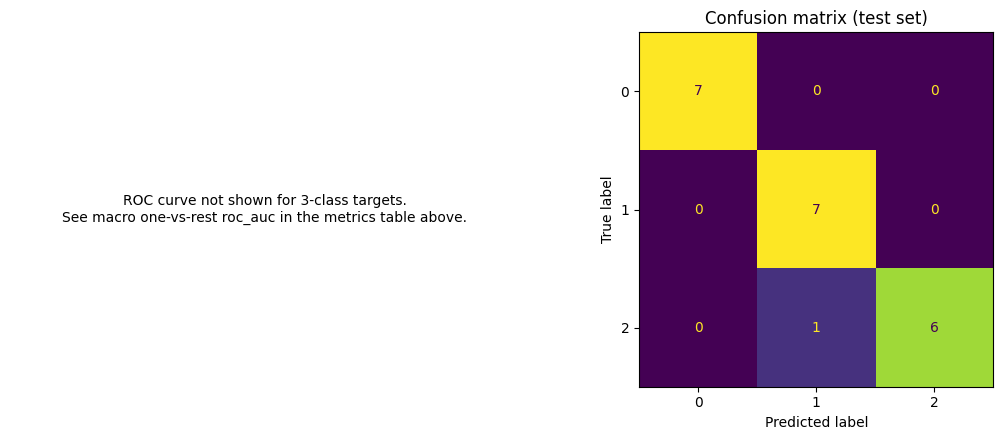

In [33]:
n_classes = y_test.nunique()
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

if n_classes == 2:
    fpr, tpr, _ = roc_curve(y_test, proba[:, 1])
    roc_auc_value = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc_value:.3f}")
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray")
    axes[0].set_xlabel("False Positive Rate")
    axes[0].set_ylabel("True Positive Rate")
    axes[0].set_title("ROC curve (test set)")
    axes[0].legend()
else:
    # ROC curves are a binary-target notion; for multiclass the macro
    # one-vs-rest AUC is already in the metrics table above.
    axes[0].axis("off")
    axes[0].text(
        0.5, 0.5,
        f"ROC curve not shown for {n_classes}-class targets.\n"
        "See macro one-vs-rest roc_auc in the metrics table above.",
        ha="center", va="center", wrap=True,
    )

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm).plot(ax=axes[1], colorbar=False)
axes[1].set_title("Confusion matrix (test set)")

plt.tight_layout()
plt.show()

## 12. Narrated summary

Plain-text only — no tools, no decisions, just narrating facts already computed above.

In [34]:
summary_messages = [
    {"role": "system", "content": (
        "You are the Analyst step of a deterministic ML pipeline. Respond "
        "with 4-6 sentences of plain prose only (no JSON, no markdown "
        "fences) summarizing the given facts for a non-technical "
        "stakeholder. Do not invent any numbers not present in the input."
    )},
    {"role": "user", "content": json.dumps({
        "goal": CONFIG["goal"] or "(none given — target inferred from data alone)",
        "target_column": target_column,
        "n_candidates_tried": len(candidate_results),
        "n_candidates_passed_leakage_gate": len(passing),
        "selected_candidate": {
            "candidate_id": best.candidate_id, "template_id": best.template_id,
            "verification_verdict": selected_verification.verdict,
        },
        "final_test_metrics": {m: test_results[m].to_dict() for m in metric_names},
        "note_for_summary": (
            "Mention the verification concerns briefly as a caveat for human review."
            if selected_verification.concerns else None
        ),
    }, indent=2)},
]
summary_response = client.call(summary_messages, model=default_model, max_tokens=400)
display(Markdown(f"**Summary:**\n\n{summary_response.text}"))
analyst_transcript_path = write_transcript(
    "analyst_summary", summary_messages + [{"role": "assistant", "content": summary_response.text}],
)
print(f"Transcript: {analyst_transcript_path}")

**Summary:**

Our machine learning system successfully learned to predict the species of iris flowers with very high accuracy. The model achieved a test accuracy of 95.24%, meaning it correctly identified the species in most cases. The system used a pipeline template that combined different machine learning techniques to make these predictions. The model's performance was validated using statistical methods, with confidence intervals showing strong results across multiple metrics including ROC AUC and precision-recall AUC. The system passed all data leakage checks, ensuring that the results are reliable and not due to accidental information spillage. This high-performance model can now be used to accurately classify iris flowers based on their measured characteristics.

Transcript: runs/run_975e8055/transcripts/analyst_summary_01.json


## 13. Write a report + list this run's artifacts

In [35]:
report = {
    "run_id": run_id, "model": default_model, "status": "success",
    "target_column": target_column,
    "selected_candidate": {
        "candidate_id": best.candidate_id, "template_id": best.template_id,
        "verification_verdict": selected_verification.verdict,
        "verification_concerns": selected_verification.concerns,
    },
    "final_test_metrics": {m: test_results[m].to_dict() for m in metric_names},
    "final_summary": summary_response.text,
}
(run_dir / "notebook_report.json").write_text(json.dumps(report, indent=2, default=str))
print(f"Report written to {run_dir / 'notebook_report.json'}")

print("\nFiles written this run:")
for p in sorted(run_dir.rglob("*")):
    if p.is_file():
        print(" ", p)  # already relative — we chdir'd to REPO_ROOT in cell 0

Report written to runs/run_975e8055/notebook_report.json

Files written this run:
  runs/run_975e8055/notebook_report.json
  runs/run_975e8055/trace.jsonl
  runs/run_975e8055/transcripts/analyst_summary_01.json
  runs/run_975e8055/transcripts/feature_engineering_01.json
  runs/run_975e8055/transcripts/intake_01.json
  runs/run_975e8055/transcripts/modeling_01.json
  runs/run_975e8055/transcripts/modeling_02.json
  runs/run_975e8055/transcripts/profiler_01.json
  runs/run_975e8055/transcripts/verification_01.json


## 14. Inspect a transcript

Every agent call above wrote its full conversation to
`runs/<run_id>/transcripts/`. This is what makes a run auditable after
the fact — not just "what metrics came out", but "what did the
Profiler agent actually see, and what did it say back". Here's the
Profiler's, as an example — swap in any path printed above (e.g. a
`modeling_02.json` to see the second candidate's proposal, or
`verification_01.json` to see a review).

In [36]:
transcript = json.loads(profiler_transcript_path.read_text())
for message in transcript:
    role = message["role"]
    if role == "tool":
        print(f"--- {role} result ---")
        print(json.dumps(message["content"], indent=2)[:1000])
    elif message.get("tool_calls"):
        for tc in message["tool_calls"]:
            print(f"--- {role} calls tool: {tc['function']['name']} ---")
    else:
        print(f"--- {role} ---")
        content = message.get("content")
        print(json.dumps(content, indent=2) if isinstance(content, (dict, list)) else content)
    print()

--- system ---
You are the Profiler agent in a deterministic ML evaluation pipeline. You have exactly one tool: get_dataset_profile. Call it once to get factual information about the dataset — you cannot compute these facts yourself and must not guess or invent numbers.

After calling the tool, respond with ONLY valid JSON (no prose, no markdown fences) matching this schema:
{
  "summary": "<2-4 sentence plain-language summary of the dataset>",
  "recommended_split_strategy": "<copy exactly from the tool output>",
  "key_risks": ["<short bullet>", "..."],
  "recommended_next_steps": ["<short bullet>", "..."]
}

Do not contradict the tool's recommended_split_strategy or leakage_risk_flags — your job is to explain and contextualize them, not override them. If the tool output already lists leakage_risk_flags, they must appear in key_risks.

--- user ---
Profile this dataset and give your summary and recommendations.

--- assistant calls tool: get_dataset_profile ---

--- tool result ---
{